# Random Forest and Logistic Regression Experiments

#### Overview

This notebook evaluates the performance of two models, Random Forest and Logistic Regression, under different strategies for handling class imbalance.

The following approaches are considered:

- Baseline (no handling)
- Class Weight
- SMOTE
- SMOTEENN

To ensure a fair and consistent comparison, all experiments use:

- A shared preprocessing pipeline to prevent data leakage
- Stratified K-Fold cross-validation to preserve class distribution across folds
- A unified evaluation framework for consistent metric computation

All results are stored in a shared results table for comparison across models and strategies.

## Setup

In [1]:
# Add project root to system path so we can import from src/
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent / "bank-deposit-prediction"
sys.path.append(str(PROJECT_ROOT))

# Standard libraries
import pandas as pd

# Modeling
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Imbalanced learning tools
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Shared project modules
from src.shared import get_cv, get_preprocessing_steps
from src.evaluation import evaluate_model, save_results

## Data Loading
The dataset is loaded and split into features (X) and target variable (y),  
with the target encoded as binary values:
- 1 → "yes"
- 0 → "no"

In [2]:
data_path = PROJECT_ROOT / "data" / "raw" / "bank2.csv"

df = pd.read_csv(data_path, sep=';')

y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y'])

## Shared Components

The following components are used across all experiments:

- A shared preprocessing pipeline to prevent data leakage  
- Stratified K-Fold cross-validation to ensure a fair evaluation

In [3]:
# Get shared cross-validation strategy
cv = get_cv()

## Random Forest



### Baseline
We begin with the baseline model without applying any imbalance handling.

In [4]:
# Store experiment results
all_results = []

# Baseline Random Forest (no imbalance handling)
baseline_rf_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Evaluate model using cross-validation
result_rf_baseline = evaluate_model(
    "RandomForest",
    "Baseline",
    baseline_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_baseline)

result_rf_baseline

{'Model': 'RandomForest',
 'Strategy': 'Baseline',
 'Accuracy': '0.8885 ± 0.0028',
 'Precision': '0.5940 ± 0.0983',
 'Recall': '0.1209 ± 0.0231',
 'F1': '0.1989 ± 0.0308',
 'PR-AUC': '0.3482 ± 0.0273',
 'ROC-AUC': '0.7333 ± 0.0184'}

### Class Weight
Class weights are used to give more importance to the minority class during training.

In [5]:
# Class weight Random Forest
cw_rf_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]
)

# Evaluate model using cross-validation
result_rf_cw = evaluate_model(
    "RandomForest",
    "ClassWeight",
    cw_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_cw)

result_rf_cw

{'Model': 'RandomForest',
 'Strategy': 'ClassWeight',
 'Accuracy': '0.8910 ± 0.0049',
 'Precision': '0.6479 ± 0.1295',
 'Recall': '0.1151 ± 0.0303',
 'F1': '0.1947 ± 0.0493',
 'PR-AUC': '0.3418 ± 0.0378',
 'ROC-AUC': '0.7384 ± 0.0211'}

### SMOTE 
SMOTE is applied to oversample the minority class and improve model sensitivity.

In [6]:
# SMOTE Random Forest
smote_rf_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Evaluate model
result_rf_smote = evaluate_model(
    "RandomForest",
    "SMOTE",
    smote_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_smote)

result_rf_smote

{'Model': 'RandomForest',
 'Strategy': 'SMOTE',
 'Accuracy': '0.8848 ± 0.0051',
 'Precision': '0.5003 ± 0.0823',
 'Recall': '0.1516 ± 0.0294',
 'F1': '0.2320 ± 0.0416',
 'PR-AUC': '0.3234 ± 0.0372',
 'ROC-AUC': '0.7252 ± 0.0239'}

### SMOTEENN 
SMOTEENN is used as a hybrid approach to both oversample the minority class and remove noisy samples.

In [7]:
# SMOTEENN Random Forest
smoteenn_rf_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smoteenn', SMOTEENN(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Evaluate model
result_rf_smoteenn = evaluate_model(
    "RandomForest",
    "SMOTEENN",
    smoteenn_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_smoteenn)

result_rf_smoteenn

{'Model': 'RandomForest',
 'Strategy': 'SMOTEENN',
 'Accuracy': '0.8275 ± 0.0083',
 'Precision': '0.3171 ± 0.0158',
 'Recall': '0.4281 ± 0.0186',
 'F1': '0.3639 ± 0.0125',
 'PR-AUC': '0.3064 ± 0.0331',
 'ROC-AUC': '0.7207 ± 0.0273'}

## Logistic Regression

### Baseline

We begin with the baseline model without applying any imbalance handling.

In [8]:
# Baseline Logistic Regression
baseline_lr_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', LogisticRegression(max_iter=5000, random_state=42))
    ]
)

# Evaluate model
result_lr_baseline = evaluate_model(
    "LogisticRegression",
    "Baseline",
    baseline_lr_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_lr_baseline)

result_lr_baseline

{'Model': 'LogisticRegression',
 'Strategy': 'Baseline',
 'Accuracy': '0.8923 ± 0.0037',
 'Precision': '0.6605 ± 0.1145',
 'Recall': '0.1439 ± 0.0290',
 'F1': '0.2342 ± 0.0399',
 'PR-AUC': '0.3482 ± 0.0375',
 'ROC-AUC': '0.7247 ± 0.0143'}

### Class Weight
Class weights are used to give more importance to the minority class during training.

In [9]:
# Logistic Regression with class weight

lr_cw_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=5000,
            random_state=42
        ))
    ]
)

# Evaluate model
result_lr_cw = evaluate_model(
    "LogisticRegression",
    "ClassWeight",
    lr_cw_pipeline,
    X,
    y,
    cv
)

# Save results
all_results.append(result_lr_cw)

# Display results
result_lr_cw

{'Model': 'LogisticRegression',
 'Strategy': 'ClassWeight',
 'Accuracy': '0.7125 ± 0.0128',
 'Precision': '0.2188 ± 0.0073',
 'Recall': '0.5815 ± 0.0427',
 'F1': '0.3176 ± 0.0122',
 'PR-AUC': '0.3407 ± 0.0344',
 'ROC-AUC': '0.7238 ± 0.0130'}

### SMOTE
SMOTE is applied to oversample the minority class and improve model sensitivity.

In [10]:
# SMOTE Logistic Regression
lr_smote_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ]
)

# Evaluate model
result_lr_smote = evaluate_model(
    "LogisticRegression",
    "SMOTE",
    lr_smote_pipeline,
    X,
    y,
    cv
)

# Save results
all_results.append(result_lr_smote)

# Display results
result_lr_smote

{'Model': 'LogisticRegression',
 'Strategy': 'SMOTE',
 'Accuracy': '0.7211 ± 0.0124',
 'Precision': '0.2252 ± 0.0059',
 'Recall': '0.5815 ± 0.0346',
 'F1': '0.3244 ± 0.0084',
 'PR-AUC': '0.3350 ± 0.0388',
 'ROC-AUC': '0.7166 ± 0.0178'}

### SMOTEENN 
SMOTEENN is used as a hybrid approach to both oversample the minority class and remove noisy samples.

In [11]:
# SMOTEENN Logistic Regression
lr_smoteenn_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smoteenn', SMOTEENN(random_state=42)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ]
)

# Evaluate model
result_lr_smoteenn = evaluate_model(
    "LogisticRegression",
    "SMOTEENN",
    lr_smoteenn_pipeline,
    X,
    y,
    cv
)

# Save results
all_results.append(result_lr_smoteenn)

# Display results
result_lr_smoteenn

{'Model': 'LogisticRegression',
 'Strategy': 'SMOTEENN',
 'Accuracy': '0.5417 ± 0.0202',
 'Precision': '0.1680 ± 0.0072',
 'Recall': '0.7524 ± 0.0428',
 'F1': '0.2745 ± 0.0115',
 'PR-AUC': '0.3284 ± 0.0279',
 'ROC-AUC': '0.7205 ± 0.0172'}

### Results Summary

All experiment results are stored in a shared table for consistent comparison.

In [12]:
# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Save to shared results table
save_results(results_df)

In [13]:
results_path = PROJECT_ROOT / "results" / "experiment_results.csv"
results = pd.read_csv(results_path)

results

,Model,Strategy,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
0,XGBoost,Baseline,0.8830 ± 0.0048,0.4765 ± 0.0576,0.1784 ± 0.0353,0.2590 ± 0.0447,0.3037 ± 0.0329,0.7020 ± 0.0049
1,XGBoost,ClassWeight,0.8498 ± 0.0070,0.3300 ± 0.0308,0.2936 ± 0.0394,0.3099 ± 0.0313,0.2791 ± 0.0381,0.6806 ± 0.0194
2,XGBoost,SMOTE,0.8834 ± 0.0023,0.4829 ± 0.0311,0.1765 ± 0.0372,0.2567 ± 0.0431,0.3178 ± 0.0177,0.7172 ± 0.0150
3,XGBoost,SMOTEENN,0.8290 ± 0.0041,0.3266 ± 0.0061,0.4549 ± 0.0160,0.3800 ± 0.0061,0.3323 ± 0.0215,0.7270 ± 0.0142
4,RandomForest,Baseline,0.8885 ± 0.0028,0.5940 ± 0.0983,0.1209 ± 0.0231,0.1989 ± 0.0308,0.3482 ± 0.0273,0.7333 ± 0.0184
5,RandomForest,ClassWeight,0.8910 ± 0.0049,0.6479 ± 0.1295,0.1151 ± 0.0303,0.1947 ± 0.0493,0.3418 ± 0.0378,0.7384 ± 0.0211
6,RandomForest,SMOTE,0.8848 ± 0.0051,0.5003 ± 0.0823,0.1516 ± 0.0294,0.2320 ± 0.0416,0.3234 ± 0.0372,0.7252 ± 0.0239
7,RandomForest,SMOTEENN,0.8275 ± 0.0083,0.3171 ± 0.0158,0.4281 ± 0.0186,0.3639 ± 0.0125,0.3064 ± 0.0331,0.7207 ± 0.0273
8,LogisticRegression,Baseline,0.8923 ± 0.0037,0.6605 ± 0.1145,0.1439 ± 0.0290,0.2342 ± 0.0399,0.3482 ± 0.0375,0.7247 ± 0.0143
9,LogisticRegression,ClassWeight,0.7125 ± 0.0128,0.2188 ± 0.0073,0.5815 ± 0.0427,0.3176 ± 0.0122,0.3407 ± 0.0344,0.7238 ± 0.0130


## Model Interpretation

This section focuses on the interpretation of the second-best performing model, Random Forest with SMOTEENN. Feature importance is first examined to identify the most influential variables, followed by SHAP analysis for a more detailed understanding of how features affect the model’s predictions.

### Setup

In [14]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline as ImbPipeline
from src.shared import drop_columns, transform_pdays

final_model=smoteenn_rf_pipeline
final_model.fit(X, y);

### Feature Importance
The following shows the top features based on the Random Forest model’s importance scores.

In [15]:
# Get feature names after preprocessing
preprocessor = final_model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [16]:
# Extract the trained Random Forest from the pipeline

rf_model = final_model.named_steps['model'] 

In [17]:
# Get feature importance scores and sort them
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Display top 10 most important features
rf_importance.head(10)

num__balance             0.058639
cat__contact_cellular    0.053050
cat__contact_unknown     0.049974
num__age                 0.045914
num__campaign            0.044437
cat__marital_married     0.034431
cat__job_blue-collar     0.029852
cat__loan_no             0.029586
cat__housing_yes         0.026304
cat__month_jul           0.025665
dtype: float64

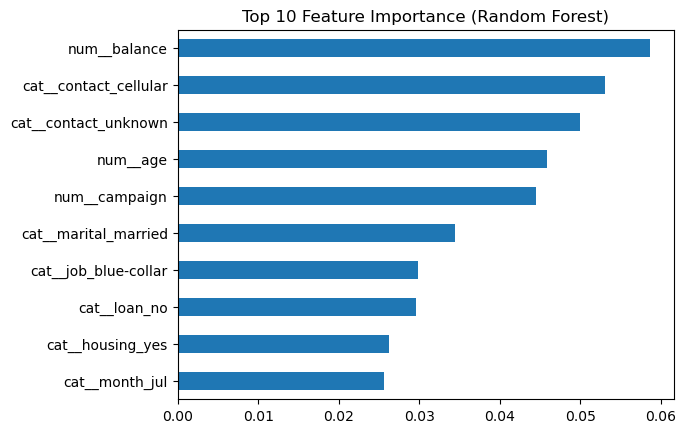

In [18]:
# Plot top 10 feature importance
rf_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

### SHAP Analysis
SHAP (SHapley Additive exPlanations) is used to provide a more detailed interpretation of feature contributions, showing how each feature influences the model’s predictions.

⌛ Running SHAP analysis...


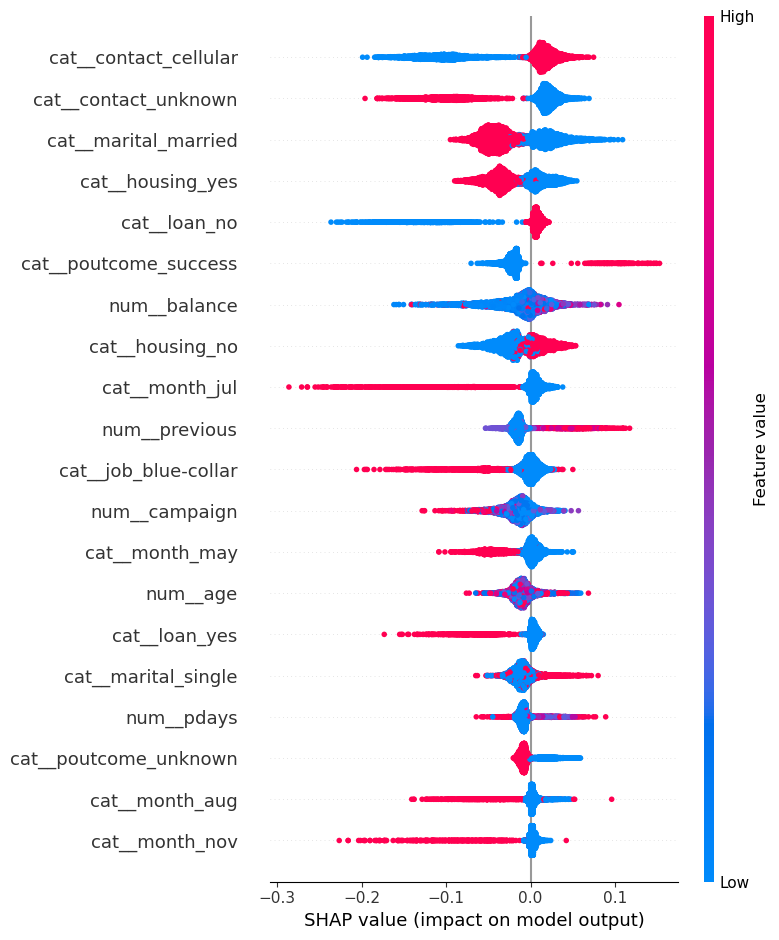

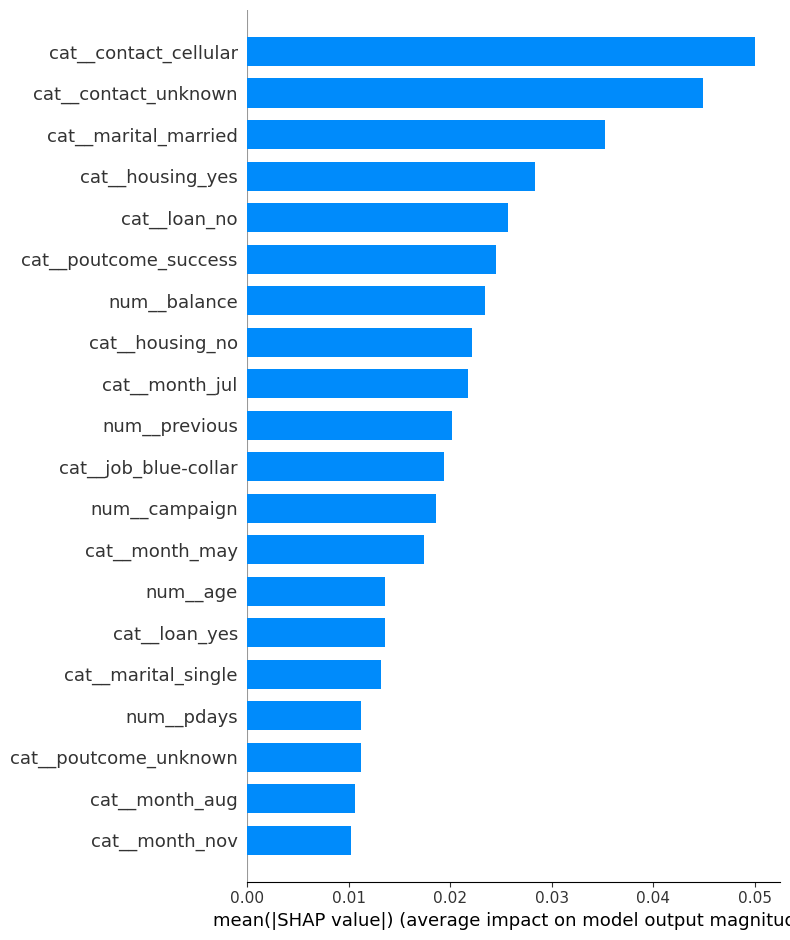

In [19]:
print("⌛ Running SHAP analysis...")

# Apply preprocessing 
X_temp = final_model.named_steps['drop_columns'].transform(X)
X_temp = final_model.named_steps['pdays_transform'].transform(X_temp)

X_transformed = final_model.named_steps['preprocessor'].transform(X_temp)

# Convert sparse → dense
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()
else:
    X_transformed = X_transformed

#  Get feature names
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

#  Convert to DataFrame
X_df = pd.DataFrame(X_transformed, columns=feature_names)

#  Extract model
rf_model = final_model.named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_df)

# Handle both possible formats
if isinstance(shap_values, list):
    final_shap = shap_values[1]
else:
    final_shap = shap_values[:, :, 1]
    
#  Plots
shap.summary_plot(final_shap, X_df)
shap.summary_plot(final_shap, X_df, plot_type="bar")